In [3]:
!pip install h5py numpy pandas matplotlib

In [5]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

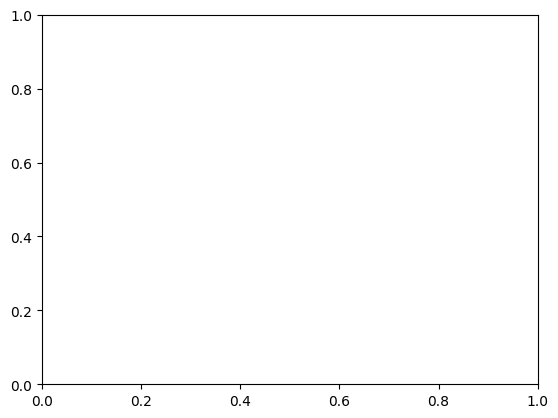

In [6]:
#Download NEON helper module
import os, sys
import requests

def download_url(url, download_dir):
    if not os.path.isdir(download_dir):
        os.makedirs(download_dir)
    filename = url.split('/')[-1]
    r = requests.get(url, allow_redirects=True)
    with open(os.path.join(download_dir, filename), 'wb') as file_object:
        file_object.write(r.content)

module_url = "https://raw.githubusercontent.com/NEONScience/NEON-Data-Skills/main/tutorials/Python/AOP/aop_python_modules/neon_aop_hyperspectral.py"
download_url(module_url, 'python_modules')

sys.path.insert(0, 'python_modules')
import neon_aop_hyperspectral as neon_hs

In [7]:
# Read file
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# your file name
h5_tile = r"D:\TMHRS\Hyperspectral\NEON_refl-surf-dir-ortho-mosaic\NEON_refl-surf-dir-ortho-mosaic\NEON.D17.SJER.DP3.30006.001.2013-06.basic.20260331T024351Z.RELEASE-2026\NEON_D17_SJER_DP3_256000_4106000_reflectance.h5"

# read in the data
sjer_refl, sjer_refl_md, wavelengths = neon_hs.aop_h5refl2array(h5_tile, 'Reflectance')

Reading in  D:\TMHRS\Hyperspectral\NEON_refl-surf-dir-ortho-mosaic\NEON_refl-surf-dir-ortho-mosaic\NEON.D17.SJER.DP3.30006.001.2013-06.basic.20260331T024351Z.RELEASE-2026\NEON_D17_SJER_DP3_256000_4106000_reflectance.h5


In [8]:
#Check metadata
for item in sorted(sjer_refl_md):
    print(item + ':', sjer_refl_md[item])

print('\nSJER Tile Reflectance Stats:')
print('min:', np.nanmin(sjer_refl))
print('max:', round(np.nanmax(sjer_refl), 2))
print('mean:', round(np.nanmean(sjer_refl), 2))

EPSG: 32611
bad_band_window1: [1340 1445]
bad_band_window2: [1790 1955]
ext_dict: {'xMin': 256000.0, 'xMax': 257000.0, 'yMin': 4106000.0, 'yMax': 4107000.0}
extent: (256000.0, 257000.0, 4106000.0, 4107000.0)
no_data_value: -9999.0
projection: b'+proj=UTM +zone=11 +ellps=WGS84 +datum=WGS84 +units=m +no_defs'
res: {'pixelWidth': 1.0, 'pixelHeight': 1.0}
scale_factor: 10000.0
shape: (1000, 1000, 426)
source: D:\TMHRS\Hyperspectral\NEON_refl-surf-dir-ortho-mosaic\NEON_refl-surf-dir-ortho-mosaic\NEON.D17.SJER.DP3.30006.001.2013-06.basic.20260331T024351Z.RELEASE-2026\NEON_D17_SJER_DP3_256000_4106000_reflectance.h5

SJER Tile Reflectance Stats:
min: -100
max: 15346
mean: 2228.22


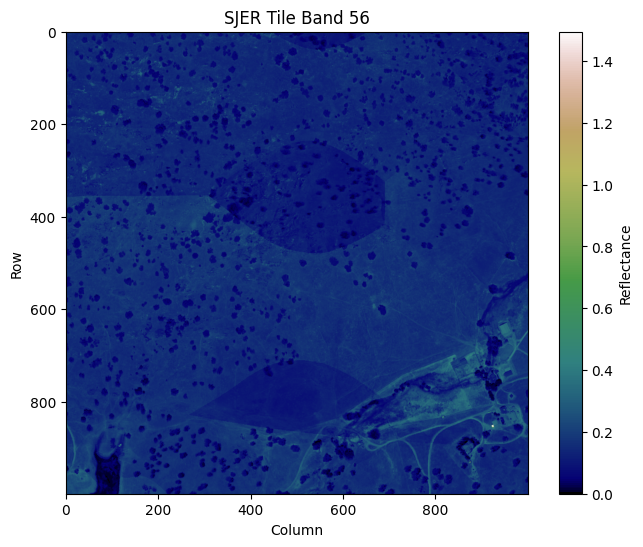

In [9]:
#Plot one band image
#Band 56 (index 55 because Python starts from 0)
sjer_band56 = sjer_refl[:, :, 55] / sjer_refl_md['scale_factor']

plt.figure(figsize=(8,6))
plt.imshow(sjer_band56, cmap='gist_earth')
plt.colorbar(label='Reflectance')
plt.title('SJER Tile Band 56')
plt.xlabel('Column')
plt.ylabel('Row')
plt.show()

In [9]:
#This extracts the reflectance values of all 426 bands for a single pixel.
# Select center pixel
row = sjer_refl.shape[0] // 2
col = sjer_refl.shape[1] // 2

# Create dataframe for that pixel
sjer_pixel_df = pd.DataFrame()
sjer_pixel_df['reflectance'] = sjer_refl[row, col, :] / sjer_refl_md['scale_factor']
sjer_pixel_df['wavelengths'] = wavelengths

print("Selected pixel:", row, col)
print(sjer_pixel_df.head())
print(sjer_pixel_df.tail())

Selected pixel: 500 500
   reflectance  wavelengths
0       0.0910   382.346497
1       0.0715   387.355286
2       0.0624   392.364105
3       0.0600   397.372986
4       0.0551   402.381805
     reflectance  wavelengths
421       0.1963  2491.063477
422       0.3267  2496.072266
423       0.2860  2501.081055
424       0.3196  2506.089844
425       0.3909  2511.098877


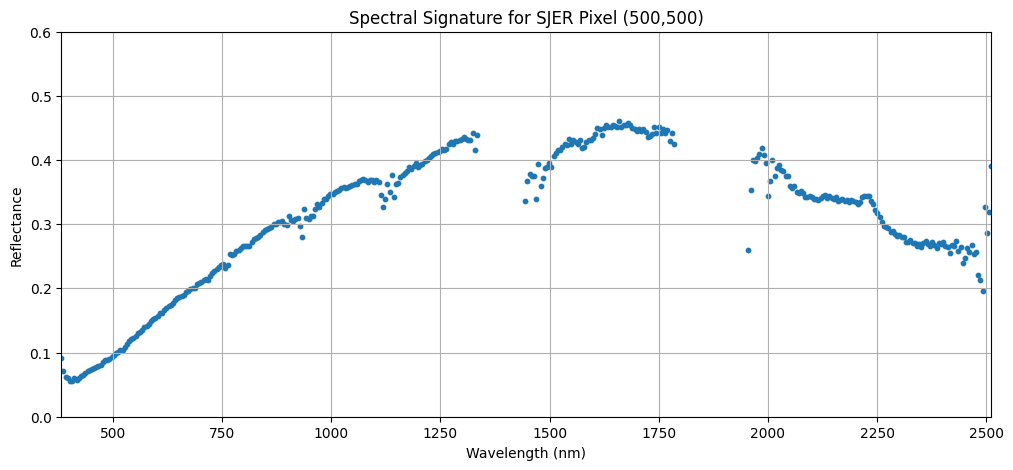

In [11]:
#Plot spectral signature)
plt.figure(figsize=(12,5))
plt.scatter(sjer_pixel_df['wavelengths'], sjer_pixel_df['reflectance'], s=10)
plt.title(f'Spectral Signature for SJER Pixel ({row},{col})')
plt.xlim(np.min(sjer_pixel_df['wavelengths']), np.max(sjer_pixel_df['wavelengths']))
plt.ylim(0, 0.6)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Reflectance")
plt.grid(True)
plt.show()

In [10]:
# to claen the graph
bbw1 = sjer_refl_md['bad_band_window1']
bbw2 = sjer_refl_md['bad_band_window2']

print("Bad Band Window 1:", bbw1)
print("Bad Band Window 2:", bbw2)

w = wavelengths.copy()
w[((w >= bbw1[0]) & (w <= bbw1[1])) | ((w >= bbw2[0]) & (w <= bbw2[1]))] = np.nan

# mask last 10 noisy bands
w[-10:] = np.nan

Bad Band Window 1: [1340 1445]
Bad Band Window 2: [1790 1955]


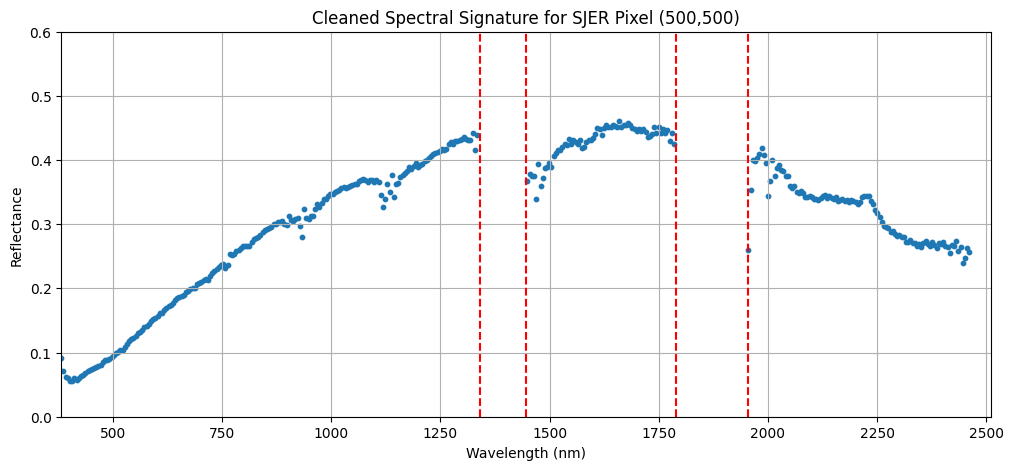

In [11]:
#Cleaned spectral signature plot
clean_pixel_df = pd.DataFrame()
clean_pixel_df['reflectance'] = sjer_refl[row, col, :] / sjer_refl_md['scale_factor']
clean_pixel_df['wavelengths'] = w

plt.figure(figsize=(12,5))
plt.scatter(clean_pixel_df['wavelengths'], clean_pixel_df['reflectance'], s=10)
plt.title(f'Cleaned Spectral Signature for SJER Pixel ({row},{col})')
plt.xlim(np.nanmin(wavelengths), np.nanmax(wavelengths))
plt.ylim(0, 0.6)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Reflectance")
plt.grid(True)

# show bad band boundaries
plt.axvline(bbw1[0], color='red', linestyle='--')
plt.axvline(bbw1[1], color='red', linestyle='--')
plt.axvline(bbw2[0], color='red', linestyle='--')
plt.axvline(bbw2[1], color='red', linestyle='--')

plt.show()

In [12]:
pixels = {
    "Vegetation": (400, 400),
    "Soil": (600, 600),
    "Dark Area": (200, 200)
}

multi_pixel_df = pd.DataFrame()

for label, (r, c) in pixels.items():
    multi_pixel_df[label] = sjer_refl[r, c, :] / sjer_refl_md['scale_factor']

multi_pixel_df['wavelengths'] = wavelengths

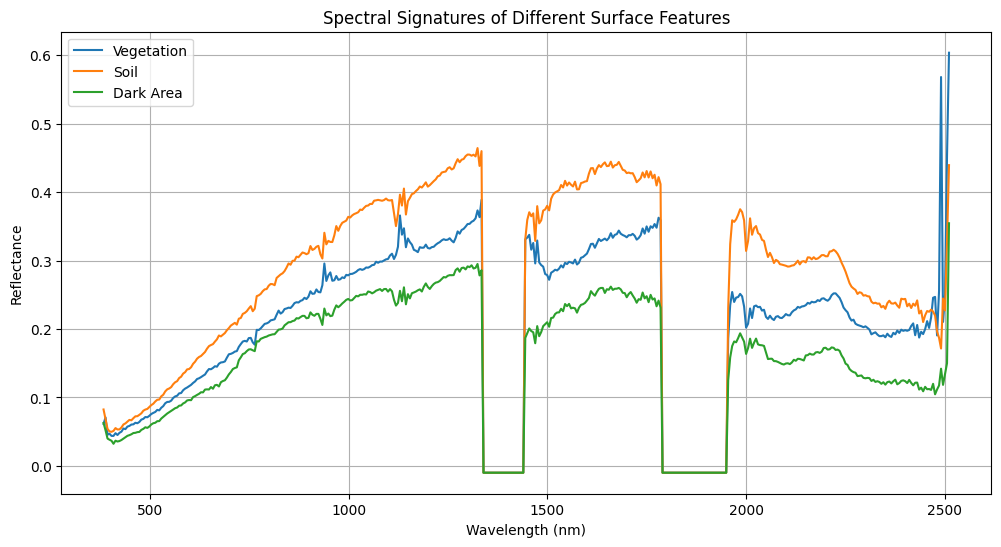

In [13]:
plt.figure(figsize=(12,6))

for label in pixels.keys():
    plt.plot(multi_pixel_df['wavelengths'], multi_pixel_df[label], label=label)

plt.xlabel("Wavelength (nm)")
plt.ylabel("Reflectance")
plt.title("Spectral Signatures of Different Surface Features")
plt.legend()
plt.grid(True)
plt.show()